In [2]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


In [3]:
# импортируем необходимые библиотеки
import re
import bottleneck as bn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

# импортируем необходимые классы
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from catboost import CatBoostRegressor

# импортируем из модуля sklearn.model_selection
# функцию train_test_split()
from sklearn.model_selection import train_test_split

# # импортируем класс TimeSeriesSplit, реализующий
# # стратегии перекрестной проверки
# # для временных рядов
# from sklearn.model_selection import TimeSeriesSplit

# импортируем функцию mean_squared_error()
from sklearn.metrics import mean_squared_error

# импортируем модуль warnings
import warnings

#Обработка набора Flats_timeseries

In [5]:
# записываем CSV-файл в объект DataFrame
import urllib.request
urllib.request.urlretrieve(
    'https://github.com/MinyaevAndrey/Data_Preprocessing_in_Python/blob/main/code/Data/Flats_timeseries.csv?raw=true',
    'Flats_timeseries.csv'
)

flat_data = pd.read_csv('Flats_timeseries.csv', sep=';')

# выводим первые 5 наблюдений датафрейма
flat_data.head()

,Date_Create,Value_abs
0,22.08.2016,1450000
1,23.08.2016,1650000
2,24.08.2016,2250000
3,25.08.2016,1960000
4,26.08.2016,1950000


In [6]:
flat_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date_Create  20 non-null     object
 1   Value_abs    20 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 452.0+ bytes


In [8]:
# преобразовываем в формат даты
flat_data['Date_Create'] = pd.to_datetime(flat_data['Date_Create'], format='%d.%m.%Y')

# сортируем данные по дате сделки
# (от самой ранней к самой поздней)
flat_data = flat_data.sort_values(by='Date_Create')

# создадим некоторые календарные признаки
flat_data['dayofweek'] = pd.DatetimeIndex(flat_data['Date_Create']).dayofweek
flat_data['weekend'] = np.where(flat_data['dayofweek'].isin([5, 6]), 1, 0)

# сделаем столбец Date_Create индексом
flat_data = flat_data.set_index('Date_Create')
flat_data

,Value_abs,dayofweek,weekend
Date_Create,,,
2016-08-22,1450000,0,0
2016-08-23,1650000,1,0
2016-08-24,2250000,2,0
2016-08-25,1960000,3,0
2016-08-26,1950000,4,0
2016-08-27,1700000,5,1
2016-08-28,1550000,6,1
2016-08-29,2330000,0,0
2016-08-30,1900000,1,0


In [9]:
# выполняем разбиение на обучающую и тестовую выборки,
# учитывающее временную структуру
X_flat_tr, X_flat_tst, y_flat_tr, y_flat_tst = train_test_split(
    flat_data.drop('Value_abs', axis=1),
    flat_data['Value_abs'],
    test_size=6,
    shuffle=False
)

In [10]:
# смотрим обучающую выборку
X_flat_tr

,dayofweek,weekend
Date_Create,,
2016-08-22,0,0
2016-08-23,1,0
2016-08-24,2,0
2016-08-25,3,0
2016-08-26,4,0
2016-08-27,5,1
2016-08-28,6,1
2016-08-29,0,0
2016-08-30,1,0


In [11]:
# смотрим тестовую выборку
X_flat_tst

,dayofweek,weekend
Date_Create,,
2016-09-05,0,0
2016-09-06,1,0
2016-09-07,2,0
2016-09-08,3,0
2016-09-09,4,0
2016-09-10,5,1


#Обработка набора monthly_australian_wine_sales

In [13]:
# загружаем набор о ежемесячных продажах вина в Австралии
import urllib.request
urllib.request.urlretrieve(
    'https://github.com/MinyaevAndrey/Data_Preprocessing_in_Python/blob/main/code/Data/monthly_australian_wine_sales.csv?raw=true',
    'monthly_australian_wine_sales.csv'
)
# с помощью параметра date_format и функции pd.to_datetime() мы можем задать точный формат даты для парсинга.
wine_df = pd.read_csv('monthly_australian_wine_sales.csv',
                      index_col=['month'],
                      parse_dates=['month'],
                      date_format=lambda col: pd.to_datetime(col, format='%Y-%m-%d')
)
wine_df.head()

,sales
month,
1980-01-01,15136
1980-02-01,16733
1980-03-01,20016
1980-04-01,17708
1980-05-01,18019


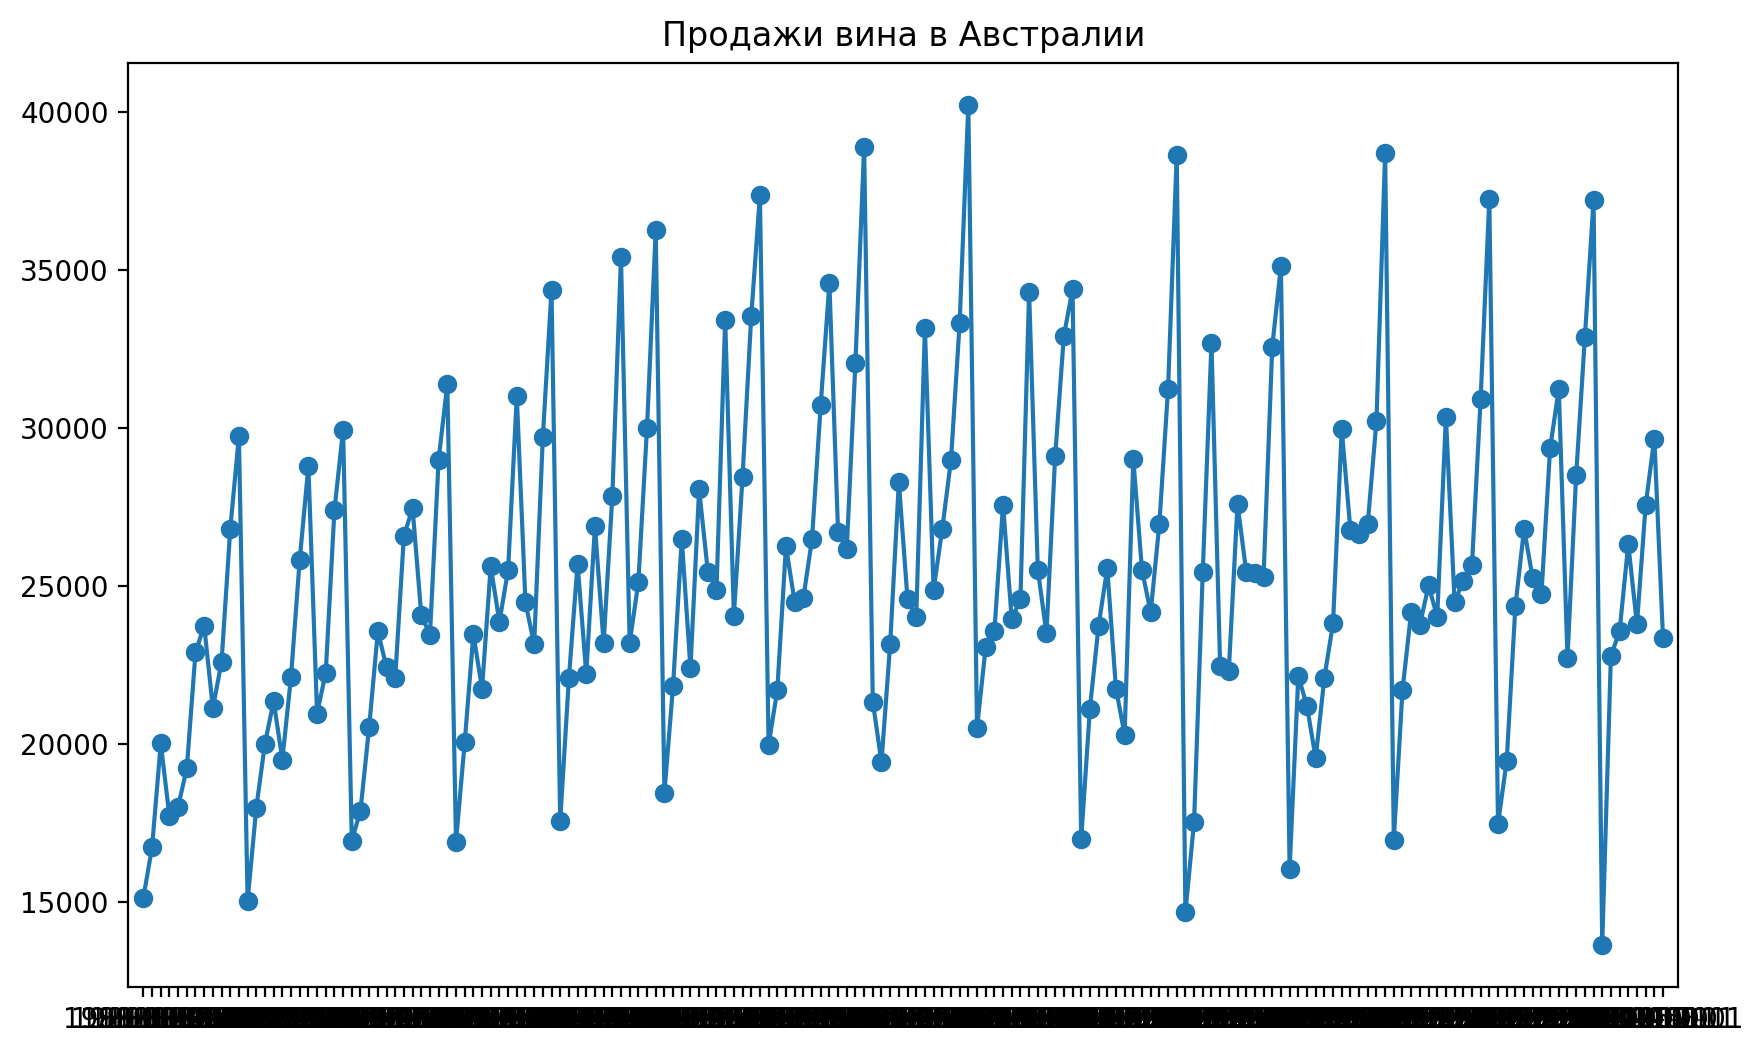

In [16]:
# визуализируем временной ряд

# задаем размер графика
fig, ax = plt.subplots(figsize=(10, 6))

# строим график
ax.plot(wine_df['sales'], marker='o')

# задаем заголовок графика
ax.set_title("Продажи вина в Австралии")

# задаем начало оси x с отступом
ax.margins(x=0.01)

# задаем координатную сетку
# ax.grid();

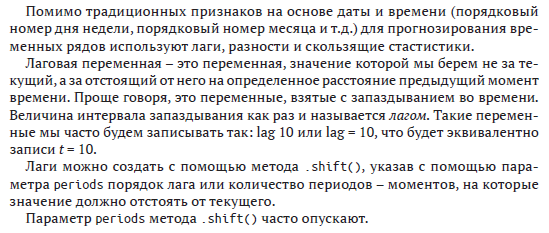

In [ ]:
# создаем набор продаж
example = pd.DataFrame(
    {'sales': [2400, 2800, 2500, 2890, 2610, 2500, 2750, 2700, 2250, 2350, 2550, 3000]},
    index=pd.date_range(start='2018-01-09', periods=12)
)

# лаг с запаздыванием на 3 дня
example['Lag3'] = example['sales'].shift(periods=3)
# лаг с запаздыванием на 4 дня
example['Lag4'] = example['sales'].shift(periods=4)
# лаг с запаздыванием на 5 дней
example['Lag5'] = example['sales'].shift(periods=5)
# лаг с запаздыванием на 6 дней
example['Lag6'] = example['sales'].shift(periods=6)
# лаг равен длине набора
example['Lag12'] = example['sales'].shift(periods=12)
# лаг превышает длину набора
example['Lag13'] = example['sales'].shift(periods=13)
# смотрим результаты
example

,sales,Lag3,Lag4,Lag5,Lag6,Lag12,Lag13
2018-01-09,2400,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-10,2800,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-11,2500,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-12,2890,2400.0,NaN,NaN,NaN,NaN,NaN
2018-01-13,2610,2800.0,2400.0,NaN,NaN,NaN,NaN
2018-01-14,2500,2500.0,2800.0,2400.0,NaN,NaN,NaN
2018-01-15,2750,2890.0,2500.0,2800.0,2400.0,NaN,NaN
2018-01-16,2700,2610.0,2890.0,2500.0,2800.0,NaN,NaN
2018-01-17,2250,2500.0,2610.0,2890.0,2500.0,NaN,NaN
2018-01-18,2350,2750.0,2500.0,2610.0,2890.0,NaN,NaN


In [ ]:
# удалим переменные Lag12 и Lag13
example.drop(['Lag12', 'Lag13'], axis=1, inplace=True)
# разбиваем набор на обучающую и тестовую выборки
train, test = example[0:len(example)-4], example[len(example)-4:]

In [ ]:
# смотрим обучающую выборку
train

,sales,Lag3,Lag4,Lag5,Lag6
2018-01-09,2400,NaN,NaN,NaN,NaN
2018-01-10,2800,NaN,NaN,NaN,NaN
2018-01-11,2500,NaN,NaN,NaN,NaN
2018-01-12,2890,2400.0,NaN,NaN,NaN
2018-01-13,2610,2800.0,2400.0,NaN,NaN
2018-01-14,2500,2500.0,2800.0,2400.0,NaN
2018-01-15,2750,2890.0,2500.0,2800.0,2400.0
2018-01-16,2700,2610.0,2890.0,2500.0,2800.0


In [ ]:
# смотрим тестовую выборку
test

,sales,Lag3,Lag4,Lag5,Lag6
2018-01-17,2250,2500.0,2610.0,2890.0,2500.0
2018-01-18,2350,2750.0,2500.0,2610.0,2890.0
2018-01-19,2550,2700.0,2750.0,2500.0,2610.0
2018-01-20,3000,2250.0,2700.0,2750.0,2500.0


In [ ]:
# создаем набор продаж
example = pd.DataFrame(
    {'sales': [2400, 2800, 2500, 2890, 2610, 2500,
               2750, 2700, 2250, 2350, 2550, 3000]},
    index=pd.date_range(start='2018-01-09', periods=12)
)

# значения в наблюдениях, которые будут приходиться на тест
# (последние 4 наблюдения), заменяем на значения NaN
HORIZON = 4
example['sales'].iloc[-HORIZON:] = np.NaN

# создаем лаги, лаги меньше горизонта прогнозирования
# получат пропуски в наблюдениях, приходящихся на тест,
# при этом чем меньше порядок лага горизонта
# прогнозирования, тем больше пропусков в тесте
# лаг с запаздыванием на 1 день
example['Lag1'] = example['sales'].shift(1)
# лаг с запаздыванием на 2 дня
example['Lag2'] = example['sales'].shift(2)
# лаг с запаздыванием на 3 дня
example['Lag3'] = example['sales'].shift(3)
# лаг с запаздыванием на 4 дня
example['Lag4'] = example['sales'].shift(4)
# лаг с запаздыванием на 5 дней
example['Lag5'] = example['sales'].shift(5)
example

,sales,Lag1,Lag2,Lag3,Lag4,Lag5
2018-01-09,2400.0,NaN,NaN,NaN,NaN,NaN
2018-01-10,2800.0,2400.0,NaN,NaN,NaN,NaN
2018-01-11,2500.0,2800.0,2400.0,NaN,NaN,NaN
2018-01-12,2890.0,2500.0,2800.0,2400.0,NaN,NaN
2018-01-13,2610.0,2890.0,2500.0,2800.0,2400.0,NaN
2018-01-14,2500.0,2610.0,2890.0,2500.0,2800.0,2400.0
2018-01-15,2750.0,2500.0,2610.0,2890.0,2500.0,2800.0
2018-01-16,2700.0,2750.0,2500.0,2610.0,2890.0,2500.0
2018-01-17,NaN,2700.0,2750.0,2500.0,2610.0,2890.0
2018-01-18,NaN,NaN,2700.0,2750.0,2500.0,2610.0


In [ ]:
# удалим лаги по паттерну 'Lag'
example.drop(example.filter(regex='Lag').columns, axis=1,
             inplace=True)
# создаем обучающую выборку – первые 8
# наблюдений исходного набора
train = example.iloc[:-HORIZON]
train

,sales
2018-01-09,2400.0
2018-01-10,2800.0
2018-01-11,2500.0
2018-01-12,2890.0
2018-01-13,2610.0
2018-01-14,2500.0
2018-01-15,2750.0
2018-01-16,2700.0


In [ ]:
# пишем функцию для создания лагов
# в обучающей и тестовой выборках
def calculate_lags(train, target, horizon, lags_range,
                   freq='D', aggregate=False):
    """
    Создает лаги в обучающей и тестовой выборках.

    Параметры
    ----------
    train:
        Обучающий набор.
    target:
        Название зависимой переменной.
    horizon:
        Горизонт прогнозирования.
    lags_range:
        Диапазон значений порядка лагов.
    freq: str, значение по умолчанию 'D'
        Частота временного ряда.
    aggregate: bool, значение по умолчанию False
        Вычисляет агрегированный лаг.
    """
    if min(lags_range) < horizon:
        warnings.warn(f"\nКоличество периодов для лагов нужно задавать\n"
                      f"равным или больше горизонта прогнозирования")

    if pd.__version__ >= '1.4':
        # создаем метки времени для горизонта
        future_dates = pd.date_range(start=train.index[-1],
                                     periods=horizon + 1,
                                     freq=freq,
                                     inclusive='right')
    else:
        # создаем метки времени для горизонта
        future_dates = pd.date_range(start=train.index[-1],
                                     periods=horizon + 1,
                                     freq=freq,
                                     closed='right')
    # формируем новый удлиненный индекс
    new_index = train.index.append(future_dates)
    # выполняем переиндексацию
    new_df = train.reindex(new_index)
    # создаем лаги
    for i in lags_range:
        new_df[f"Lag_{i}"] = new_df[target].shift(i)

    if aggregate and min(lags_range) >= horizon:
        # вычисляем агрегированный лаг
        new_df['Agg_Lag'] = new_df[new_df.filter(
            regex='Lag').columns].mean(axis=1)

    train = new_df.iloc[:-horizon]
    test = new_df.iloc[-horizon:]

    return train, test

In [ ]:
# создаем лаги для обучающей и тестовой выборок
train, test = calculate_lags(
    train, target='sales', horizon=4,
    lags_range=range(3, 6), freq='D')

/var/folders/x9/w1kvj6ms0p52l8j6crt19vmh0000gn/T/ipykernel_23308/2041581760.py:24: UserWarning: 
Количество периодов для лагов нужно задавать
равным или больше горизонта прогнозирования
  warnings.warn(f"\nКоличество периодов для лагов нужно задавать\n"


In [ ]:
# смотрим лаги в обучающей выборке
train

,sales,Lag_3,Lag_4,Lag_5
2018-01-09,2400.0,NaN,NaN,NaN
2018-01-10,2800.0,NaN,NaN,NaN
2018-01-11,2500.0,NaN,NaN,NaN
2018-01-12,2890.0,2400.0,NaN,NaN
2018-01-13,2610.0,2800.0,2400.0,NaN
2018-01-14,2500.0,2500.0,2800.0,2400.0
2018-01-15,2750.0,2890.0,2500.0,2800.0
2018-01-16,2700.0,2610.0,2890.0,2500.0


In [ ]:
# смотрим лаги в тестовой выборке
test

,sales,Lag_3,Lag_4,Lag_5
2018-01-17,NaN,2500.0,2610.0,2890.0
2018-01-18,NaN,2750.0,2500.0,2610.0
2018-01-19,NaN,2700.0,2750.0,2500.0
2018-01-20,NaN,NaN,2700.0,2750.0


In [ ]:
# создаем набор продаж
example = pd.DataFrame(
    {'sales': [2400, 2800, 2500, 2890, 2610, 2500,
               2750, 2700, 2250, 2350, 2550, 3000]},
    index=pd.date_range(start='2018-01-09', periods=12)
)

# создаем лаги
example['Lag3'] = example['sales'].shift(3)
example['Lag4'] = example['sales'].shift(4)
example['Lag5'] = example['sales'].shift(5)

# создаем разности на основе лагов
example['Diff_on_Lag3'] = example['Lag3'].diff()
example['Diff_on_Lag4'] = example['Lag4'].diff()
example['Diff_on_Lag5'] = example['Lag5'].diff()
example['Diff2_on_Lag4'] = example['Lag4'].diff(2)
example['Diff2_on_Lag5'] = example['Lag5'].diff(2)
example

,sales,Lag3,Lag4,Lag5,Diff_on_Lag3,Diff_on_Lag4,Diff_on_Lag5,Diff2_on_Lag4,Diff2_on_Lag5
2018-01-09,2400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-10,2800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-11,2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-12,2890,2400.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-13,2610,2800.0,2400.0,NaN,400.0,NaN,NaN,NaN,NaN
2018-01-14,2500,2500.0,2800.0,2400.0,-300.0,400.0,NaN,NaN,NaN
2018-01-15,2750,2890.0,2500.0,2800.0,390.0,-300.0,400.0,100.0,NaN
2018-01-16,2700,2610.0,2890.0,2500.0,-280.0,390.0,-300.0,90.0,100.0
2018-01-17,2250,2500.0,2610.0,2890.0,-110.0,-280.0,390.0,110.0,90.0
2018-01-18,2350,2750.0,2500.0,2610.0,250.0,-110.0,-280.0,-390.0,110.0


In [ ]:
# разбиваем набор на обучающую и тестовую выборки
train, test = example[0:len(example)-4], example[len(example)-4:]

In [ ]:
# смотрим обучающую выборку
train

,sales,Lag3,Lag4,Lag5,Diff_on_Lag3,Diff_on_Lag4,Diff_on_Lag5,Diff2_on_Lag4,Diff2_on_Lag5
2018-01-09,2400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-10,2800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-11,2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-12,2890,2400.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-13,2610,2800.0,2400.0,NaN,400.0,NaN,NaN,NaN,NaN
2018-01-14,2500,2500.0,2800.0,2400.0,-300.0,400.0,NaN,NaN,NaN
2018-01-15,2750,2890.0,2500.0,2800.0,390.0,-300.0,400.0,100.0,NaN
2018-01-16,2700,2610.0,2890.0,2500.0,-280.0,390.0,-300.0,90.0,100.0


In [ ]:
# смотрим тестовую выборку
test

,sales,Lag3,Lag4,Lag5,Diff_on_Lag3,Diff_on_Lag4,Diff_on_Lag5,Diff2_on_Lag4,Diff2_on_Lag5
2018-01-17,2250,2500.0,2610.0,2890.0,-110.0,-280.0,390.0,110.0,90.0
2018-01-18,2350,2750.0,2500.0,2610.0,250.0,-110.0,-280.0,-390.0,110.0
2018-01-19,2550,2700.0,2750.0,2500.0,-50.0,250.0,-110.0,140.0,-390.0
2018-01-20,3000,2250.0,2700.0,2750.0,-450.0,-50.0,250.0,200.0,140.0


In [ ]:
# создаем набор продаж
example = pd.DataFrame(
    {'sales': [2400, 2800, 2500, 2890, 2610, 2500,
               2750, 2700, 2250, 2350, 2550, 3000]},
    index=pd.date_range(start='2018-01-09', periods=12)
)

# создаем скользящие средние с шириной окна 3,
# шириной окна 12 и шириной окна 13
example['rolling_mean3'] = example['sales'].rolling(window=3).mean()
example['rolling_mean12'] = example['sales'].rolling(window=12).mean()
example['rolling_mean13'] = example['sales'].rolling(window=13).mean()
example

,sales,rolling_mean3,rolling_mean12,rolling_mean13
2018-01-09,2400,NaN,NaN,NaN
2018-01-10,2800,NaN,NaN,NaN
2018-01-11,2500,2566.666667,NaN,NaN
2018-01-12,2890,2730.000000,NaN,NaN
2018-01-13,2610,2666.666667,NaN,NaN
2018-01-14,2500,2666.666667,NaN,NaN
2018-01-15,2750,2620.000000,NaN,NaN
2018-01-16,2700,2650.000000,NaN,NaN
2018-01-17,2250,2566.666667,NaN,NaN
2018-01-18,2350,2433.333333,NaN,NaN


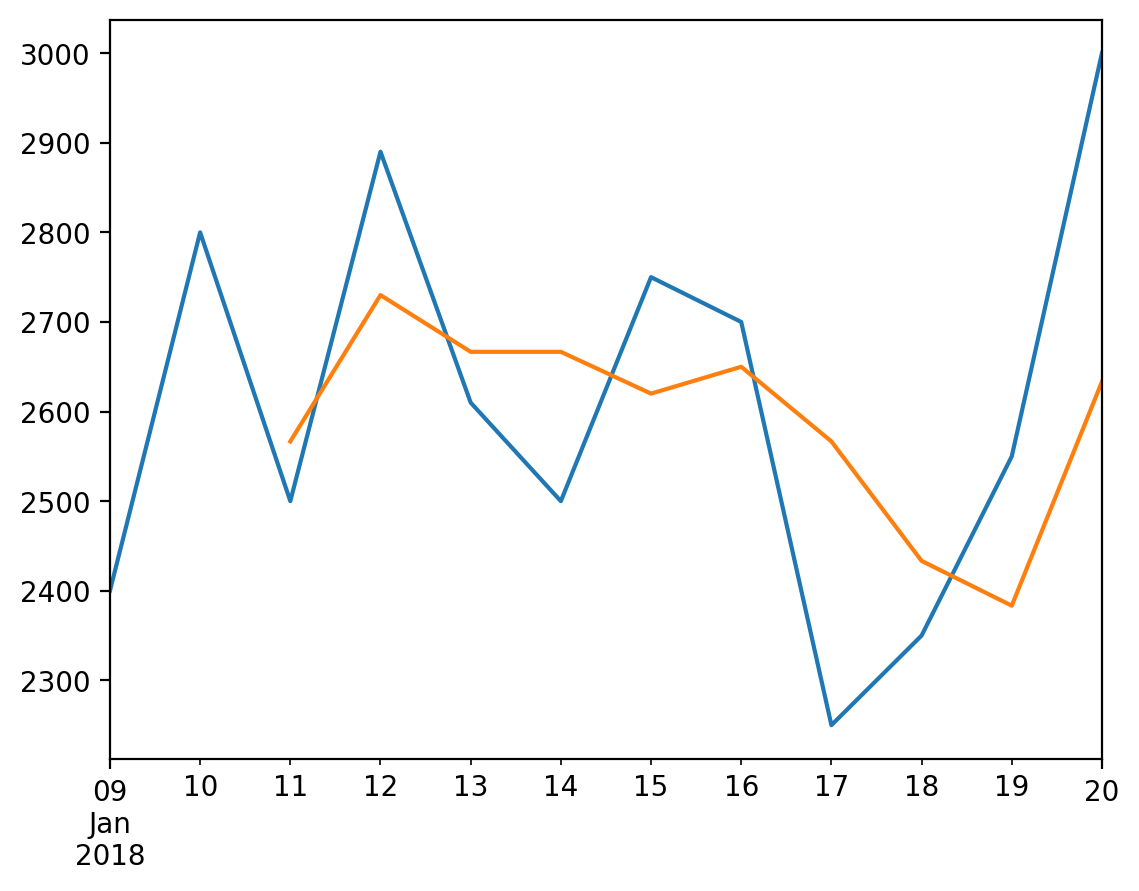

In [ ]:
# визуализируем продажи и скользящее
# среднее продаж с шириной окна 3
example['sales'].plot()
example['rolling_mean3'].plot();

In [ ]:
# создаем скользящие средние, окно шириной 3 и минимальным
# количеством наблюдений в окне, равным 2
example['rolling_mean3_min_periods_2'] = example['sales'].rolling(
    window=3, min_periods=2).mean()
example

,sales,rolling_mean3,rolling_mean12,rolling_mean13,rolling_mean3_min_periods_2
2018-01-09,2400,NaN,NaN,NaN,NaN
2018-01-10,2800,NaN,NaN,NaN,2600.000000
2018-01-11,2500,2566.666667,NaN,NaN,2566.666667
2018-01-12,2890,2730.000000,NaN,NaN,2730.000000
2018-01-13,2610,2666.666667,NaN,NaN,2666.666667
2018-01-14,2500,2666.666667,NaN,NaN,2666.666667
2018-01-15,2750,2620.000000,NaN,NaN,2620.000000
2018-01-16,2700,2650.000000,NaN,NaN,2650.000000
2018-01-17,2250,2566.666667,NaN,NaN,2566.666667
2018-01-18,2350,2433.333333,NaN,NaN,2433.333333


In [ ]:
# удалим переменные по паттерну 'rolling_mean'
example.drop(example.filter(regex='rolling_mean').columns,
             axis=1, inplace=True)
# вычисляем скользящие средние с шириной 3 и 4
# и с лагом 3, 4, 5
example['rolling_mean3_lag3'] = example['sales'].shift(periods=3).rolling(
    min_periods=1, window=3).mean()
example['rolling_mean4_lag3'] = example['sales'].shift(periods=3).rolling(
    min_periods=1, window=4).mean()
example['rolling_mean3_lag4'] = example['sales'].shift(periods=4).rolling(
    min_periods=1, window=3).mean()
example['rolling_mean4_lag4'] = example['sales'].shift(periods=4).rolling(
    min_periods=1, window=4).mean()
example['rolling_mean3_lag5'] = example['sales'].shift(periods=5).rolling(
    min_periods=1, window=3).mean()
example['rolling_mean4_lag5'] = example['sales'].shift(periods=5).rolling(
    min_periods=1, window=4).mean()
example

,sales,rolling_mean3_lag3,rolling_mean4_lag3,rolling_mean3_lag4,rolling_mean4_lag4,rolling_mean3_lag5,rolling_mean4_lag5
2018-01-09,2400,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-10,2800,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-11,2500,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-12,2890,2400.000000,2400.000000,NaN,NaN,NaN,NaN
2018-01-13,2610,2600.000000,2600.000000,2400.000000,2400.000000,NaN,NaN
2018-01-14,2500,2566.666667,2566.666667,2600.000000,2600.000000,2400.000000,2400.000000
2018-01-15,2750,2730.000000,2647.500000,2566.666667,2566.666667,2600.000000,2600.000000
2018-01-16,2700,2666.666667,2700.000000,2730.000000,2647.500000,2566.666667,2566.666667
2018-01-17,2250,2666.666667,2625.000000,2666.666667,2700.000000,2730.000000,2647.500000
2018-01-18,2350,2620.000000,2687.500000,2666.666667,2625.000000,2666.666667,2700.000000


In [ ]:
# вычисление rolling_mean3_lag3
print(np.nan)
print(np.nan)
print(np.nan)
print(2400 / 1)
print((2400 + 2800) / 2)
print((2400 + 2800 + 2500) / 3)
print((2800 + 2500 + 2890) / 3)
print((2500 + 2890 + 2610) / 3)
print((2890 + 2610 + 2500) / 3)
print((2610 + 2500 + 2750) / 3)
print((2500 + 2750 + 2700) / 3)
print((2750 + 2700 + 2250) / 3)

nan
nan
nan
2400.0
2600.0
2566.6666666666665
2730.0
2666.6666666666665
2666.6666666666665
2620.0
2650.0
2566.6666666666665


In [ ]:
# вычисление rolling_mean4_lag3
print(np.nan)
print(np.nan)
print(np.nan)
print(2400 / 1)
print((2400 + 2800) / 2)
print((2400 + 2800 + 2500) / 3)
print((2400 + 2800 + 2500 + 2890) / 4)
print((2800 + 2500 + 2890 + 2610) / 4)
print((2500 + 2890 + 2610 + 2500) / 4)
print((2890 + 2610 + 2500 + 2750) / 4)
print((2610 + 2500 + 2750 + 2700) / 4)
print((2500 + 2750 + 2700 + 2250) / 4)

nan
nan
nan
2400.0
2600.0
2566.6666666666665
2647.5
2700.0
2625.0
2687.5
2640.0
2550.0


In [ ]:
# вычисление rolling_mean3_lag4
print(np.nan)
print(np.nan)
print(np.nan)
print(np.nan)
print(2400 / 1)
print((2400 + 2800) / 2)
print((2400 + 2800 + 2500) / 3)
print((2800 + 2500 + 2890) / 3)
print((2500 + 2890 + 2610) / 3)
print((2890 + 2610 + 2500) / 3)
print((2610 + 2500 + 2750) / 3)
print((2500 + 2750 + 2700) / 3)

nan
nan
nan
nan
2400.0
2600.0
2566.6666666666665
2730.0
2666.6666666666665
2666.6666666666665
2620.0
2650.0


In [ ]:
# вычисление rolling_mean4_lag4
print(np.nan)
print(np.nan)
print(np.nan)
print(np.nan)
print(2400 / 1)
print((2400 + 2800) / 2)
print((2400 + 2800 + 2500) / 3)
print((2400 + 2800 + 2500 + 2890) / 4)
print((2800 + 2500 + 2890 + 2610) / 4)
print((2500 + 2890 + 2610 + 2500) / 4)
print((2890 + 2610 + 2500 + 2750) / 4)
print((2610 + 2500 + 2750 + 2700) / 4)

nan
nan
nan
nan
2400.0
2600.0
2566.6666666666665
2647.5
2700.0
2625.0
2687.5
2640.0


In [ ]:
# удалим переменные по паттерну 'rolling_mean'
example.drop(example.filter(regex='rolling_mean').columns,
             axis=1, inplace=True)
# значения в наблюдениях, которые будут приходиться на тест
# (последние 4 наблюдения), заменяем на значения NaN
example['sales'].iloc[-HORIZON:] = np.NaN

In [ ]:
# вычисляем скользящее среднее с шириной окна 4 и лагом 1
example['rolling_mean4_lag1'] = example['sales'].shift(
    periods=1).rolling(window=4, min_periods=1).mean()
example

,sales,rolling_mean4_lag1
2018-01-09,2400.0,NaN
2018-01-10,2800.0,2400.000000
2018-01-11,2500.0,2600.000000
2018-01-12,2890.0,2566.666667
2018-01-13,2610.0,2647.500000
2018-01-14,2500.0,2700.000000
2018-01-15,2750.0,2625.000000
2018-01-16,2700.0,2687.500000
2018-01-17,NaN,2640.000000
2018-01-18,NaN,2650.000000


In [ ]:
# вычисление rolling_mean4_lag1
print(np.nan)
print(2400 / 1)
print((2400 + 2800) / 2)
print((2400 + 2800 + 2500) / 3)
print((2400 + 2800 + 2500 + 2890) / 4)
print((2800 + 2500 + 2890 + 2610) / 4)
print((2500 + 2890 + 2610 + 2500) / 4)
print((2890 + 2610 + 2500 + 2750) / 4)
print((2610 + 2500 + 2750 + 2700) / 4)
print((2500 + 2750 + 2700) / 3)
print((2750 + 2700) / 2)
print(2700 / 1)

nan
2400.0
2600.0
2566.6666666666665
2647.5
2700.0
2625.0
2687.5
2640.0
2650.0
2725.0
2700.0


In [ ]:
# вычисляем скользящее среднее с шириной окна 4 без лага
example['rolling_mean4'] = example['sales'].rolling(
    window=4, min_periods=1).mean()
example

,sales,rolling_mean4_lag1,rolling_mean4
2018-01-09,2400.0,NaN,2400.000000
2018-01-10,2800.0,2400.000000,2600.000000
2018-01-11,2500.0,2600.000000,2566.666667
2018-01-12,2890.0,2566.666667,2647.500000
2018-01-13,2610.0,2647.500000,2700.000000
2018-01-14,2500.0,2700.000000,2625.000000
2018-01-15,2750.0,2625.000000,2687.500000
2018-01-16,2700.0,2687.500000,2640.000000
2018-01-17,NaN,2640.000000,2650.000000
2018-01-18,NaN,2650.000000,2725.000000


In [ ]:
# вычисляем скользящие средние с шириной окна
# 5 без лага и с лагом
example['rolling_mean5'] = example['sales'].rolling(
    window=5, min_periods=1).mean()
example['rolling_mean5_lag1'] = example['sales'].shift(1).rolling(
    window=5, min_periods=1).mean()
example

,sales,rolling_mean4_lag1,rolling_mean4,rolling_mean5,rolling_mean5_lag1
2018-01-09,2400.0,NaN,2400.000000,2400.000000,NaN
2018-01-10,2800.0,2400.000000,2600.000000,2600.000000,2400.000000
2018-01-11,2500.0,2600.000000,2566.666667,2566.666667,2600.000000
2018-01-12,2890.0,2566.666667,2647.500000,2647.500000,2566.666667
2018-01-13,2610.0,2647.500000,2700.000000,2640.000000,2647.500000
2018-01-14,2500.0,2700.000000,2625.000000,2660.000000,2640.000000
2018-01-15,2750.0,2625.000000,2687.500000,2650.000000,2660.000000
2018-01-16,2700.0,2687.500000,2640.000000,2690.000000,2650.000000
2018-01-17,NaN,2640.000000,2650.000000,2640.000000,2690.000000
2018-01-18,NaN,2650.000000,2725.000000,2650.000000,2640.000000


In [ ]:
# вычисление rolling_mean5
print(2400 / 1)
print((2400 + 2800) / 2)
print((2400 + 2800 + 2500) / 3)
print((2400 + 2800 + 2500 + 2890) / 4)
print((2400 + 2800 + 2500 + 2890 + 2610) / 5)
print((2800 + 2500 + 2890 + 2610 + 2500) / 5)
print((2500 + 2890 + 2610 + 2500 + 2750) / 5)
print((2890 + 2610 + 2500 + 2750 + 2700) / 5)
print((2610 + 2500 + 2750 + 2700) / 4)
print((2500 + 2750 + 2700) / 3)
print((2750 + 2700) / 2)
print(2700 / 1)

2400.0
2600.0
2566.6666666666665
2647.5
2640.0
2660.0
2650.0
2690.0
2640.0
2650.0
2725.0
2700.0


In [ ]:
# функция для создания скользящих статистик
def moving_stats(series, alpha=1, seasonality=1,
                 periods=1, min_periods=1, window=4,
                 aggfunc='mean', fillna=None):
    """
    Создает скользящие статистики.

    Параметры
    ----------
    alpha: int, по умолчанию 1
        Коэффициент авторегрессии.
    seasonality: int, по умолчанию 1
        Коэффициент сезонности.
    periods: int, по умолчанию 1
        Порядок лага, с которым вычисляем скользящие
        статистики.
    min_periods: int, по умолчанию 1
        Минимальное количество наблюдений в окне для
        вычисления скользящих статистик.
    window: int, по умолчанию 4
        Ширина окна. Не должна быть меньше
        горизонта прогнозирования.
    aggfunc: string, по умолчанию 'mean'
        Агрегирующая функция.
    fillna, int, по умолчанию None
        Стратегия импутации пропусков.
    """
    # задаем размер окна для определения
    # диапазона коэффициентов
    size = window if window != -1 else len(series) - 1
    # задаем диапазон значений коэффициентов в виде списка
    alpha_range = [alpha ** i for i in range(0, size)]
    # задаем минимально требуемое количество наблюдений
    # в окне для вычисления скользящего среднего с
    # поправкой на сезонность
    min_required_len = max(
        min_periods - 1, 0) * seasonality + 1

    # функция для получения лагов в соответствии
    # с заданной сезонностью
    def get_required_lags(series):
        # возвращает вычисленные лаги в соответствии
        # с заданной сезонностью
        return pd.Series(series.values[::-1]
                         [:: seasonality])

    # функция для вычисления скользящей статистики
    def aggregate_window(series):
        tmp_series = get_required_lags(series)
        size = len(tmp_series)
        tmp = tmp_series * alpha_range[-size:]

        if aggfunc == 'mdad':
            return tmp.to_frame().agg(
                lambda x: np.nanmedian(
                    np.abs(x - np.nanmedian(x))))
        else:
            return tmp.agg(aggfunc)

    # собственно вычисление скользящих статистик
    features = series.shift(periods=periods).rolling(
        window=seasonality * window
        if window != -1 else len(series) - 1,
        min_periods=min_required_len).aggregate(
        aggregate_window)

    # импутируем пропуски
    if fillna is not None:
        features.fillna(fillna, inplace=True)

    return features

In [ ]:
# удалим переменные по паттерну 'rolling_mean'
example.drop(example.filter(regex='rolling_mean').columns,
             axis=1, inplace=True)
# вычислим скользящее среднее с шириной окна 4 обоими способами
example['rolling_mean4_frst_method'] = moving_stats(
    example['sales'], window=4, periods=4)
example['rolling_mean4_scnd_method'] = moving_stats(
    example['sales'], window=4, periods=1, min_periods=1)
example

,sales,rolling_mean4_frst_method,rolling_mean4_scnd_method
2018-01-09,2400.0,NaN,NaN
2018-01-10,2800.0,NaN,2400.000000
2018-01-11,2500.0,NaN,2600.000000
2018-01-12,2890.0,NaN,2566.666667
2018-01-13,2610.0,2400.000000,2647.500000
2018-01-14,2500.0,2600.000000,2700.000000
2018-01-15,2750.0,2566.666667,2625.000000
2018-01-16,2700.0,2647.500000,2687.500000
2018-01-17,NaN,2700.000000,2640.000000
2018-01-18,NaN,2625.000000,2650.000000


In [ ]:
# более простая (и быстрая) функция
# для создания скользящих статистик
def fast_moving_stats(series, periods=1, min_count=1,
                      window=4,  fast=True, fillna=None,
                      aggfunc='mean'):
    """
    Создает скользящие статистики.

    Параметры
    ----------
    series:
        pandas.Series
    periods: int, по умолчанию 1
        Порядок лага, с которым вычисляем скользящие
        статистики.
    min_count: int, по умолчанию 1
        Минимальное количество наблюдений в окне для
        вычисления скользящих статистик.
    window: int, по умолчанию 4
        Ширина окна. Не должна быть меньше
        горизонта прогнозирования.
    fast: bool, по умолчанию True
        Режим вычислений скользящих статистик.
    fillna, int, по умолчанию 0
        Стратегия импутации пропусков.
    aggfunc: string, по умолчанию 'mean'
        Стратегия импутации пропусков.
    """
    if fast:
        def shift(xs, n):
            return np.concatenate((np.full(n, np.nan),
                                   xs[:-n]))

        arr = series.values
        arr = shift(xs=arr, n=periods)
        if aggfunc == 'mean':
            arr = bn.move_mean(
                arr, window=window, min_count=min_count)
        if aggfunc == 'std':
            arr = bn.move_std(
                arr, window=window, min_count=min_count)
        if aggfunc == 'sum':
            arr = bn.move_sum(
                arr, window=window, min_count=min_count)
        if aggfunc == 'median':
            arr = bn.move_median(
                arr, window=window, min_count=min_count)

        features = pd.Series(arr)
        features.index = series.index
    else:
        if aggfunc == 'mean':
            features = series.shift(
                periods=periods).rolling(
                window=window,
                min_periods=min_count).mean()
        if aggfunc == 'std':
            features = series.shift(
                periods=periods).rolling(
                window=window,
                min_periods=min_count).std()
        if aggfunc == 'sum':
            features = series.shift(
                periods=periods).rolling(
                window=window,
                min_periods=min_count).sum()
        if aggfunc == 'median':
            features = series.shift(
                periods=periods).rolling(
                window=window,
                min_periods=min_count).median()

    # импутируем пропуски
    if fillna is not None:
        features.fillna(fillna, inplace=True)

    return features

In [ ]:
# применяем нашу более простую и быструю функцию,
# вычислим скользящее среднее с шириной окна 4 обоими способами
example['roll_mean4_frst_method'] = fast_moving_stats(
    example['sales'], window=4, periods=4,
    fast=True, fillna=None, aggfunc='mean')
example['roll_mean4_scnd_method'] = fast_moving_stats(
    example['sales'], window=4, min_count=1,
    fast=True, fillna=None, aggfunc='mean')
example

,sales,rolling_mean4_frst_method,rolling_mean4_scnd_method,roll_mean4_frst_method,roll_mean4_scnd_method
2018-01-09,2400.0,NaN,NaN,NaN,NaN
2018-01-10,2800.0,NaN,2400.000000,NaN,2400.000000
2018-01-11,2500.0,NaN,2600.000000,NaN,2600.000000
2018-01-12,2890.0,NaN,2566.666667,NaN,2566.666667
2018-01-13,2610.0,2400.000000,2647.500000,2400.000000,2647.500000
2018-01-14,2500.0,2600.000000,2700.000000,2600.000000,2700.000000
2018-01-15,2750.0,2566.666667,2625.000000,2566.666667,2625.000000
2018-01-16,2700.0,2647.500000,2687.500000,2647.500000,2687.500000
2018-01-17,NaN,2700.000000,2640.000000,2700.000000,2640.000000
2018-01-18,NaN,2625.000000,2650.000000,2625.000000,2650.000000


In [ ]:
# пишем функцию конструирования календарных признаков
def create_calendar_vars(df):
    # выделяем из индекса ПОРЯДКОВЫЕ НОМЕРА КВАРТАЛОВ
    df['quarter'] = df.index.quarter
    # выделяем из индекса ПОРЯДКОВЫЕ НОМЕРА МЕСЯЦЕВ,
    # где 1 - январь, 12 - декабрь
    df['month'] = df.index.month
    # пишем функцию для создания переменной - сезон
    def get_season(month):
        if (month > 11 or month < 3):
            return 0
        elif (month == 3 or month <= 5):
            return 1
        elif (month >= 6 and month < 9):
            return 2
        else:
            return 3
    # создаем переменную - сезон
    df['season'] = df['month'].apply(
        lambda x: get_season(x))

    return df

In [ ]:
# создаем календарные признаки
wine_df = create_calendar_vars(wine_df)
wine_df.head()

,sales,quarter,month,season
month,,,,
1980-01-01,15136,1,1,0
1980-02-01,16733,1,2,0
1980-03-01,20016,1,3,1
1980-04-01,17708,2,4,1
1980-05-01,18019,2,5,1


In [ ]:
# задаем горизонт
HORIZON = 6

In [ ]:
# выведем последние HORIZON * 2 наблюдений
wine_df.tail(HORIZON * 2)

,sales,quarter,month,season
month,,,,
1993-09-01,22724,3,9,3
1993-10-01,28496,4,10,3
1993-11-01,32857,4,11,3
1993-12-01,37198,4,12,0
1994-01-01,13652,1,1,0
1994-02-01,22784,1,2,0
1994-03-01,23565,1,3,1
1994-04-01,26323,2,4,1
1994-05-01,23779,2,5,1


In [ ]:
# формируем обучающую, валидационную
# (проверочную) и тестовую выборки
train = wine_df[wine_df.index <= '1993-08-01']
valid = wine_df[(wine_df.index > '1993-08-01') &
                (wine_df.index <= '1994-02-01')]
test = wine_df[wine_df.index > '1994-02-01']

# посмотрим временные рамки выборок
print("временные рамки обучающей выборки:",
      train.index[0].strftime('%Y-%m-%d'),
      train.index[-1].strftime('%Y-%m-%d'))
print("временные рамки проверочной выборки:",
      valid.index[0].strftime('%Y-%m-%d'),
      valid.index[-1].strftime('%Y-%m-%d'))
print("временные рамки тестовой выборки:",
      test.index[0].strftime('%Y-%m-%d'),
      test.index[-1].strftime('%Y-%m-%d'))

# посмотрим размеры выборок
print("")
print(f"размер обучающей выборки: {len(train)}")
print(f"размер проверочной выборки: {len(valid)}")
print(f"размер тестовой выборки: {len(test)}")

временные рамки обучающей выборки: 1980-01-01 1993-08-01
временные рамки проверочной выборки: 1993-09-01 1994-02-01
временные рамки тестовой выборки: 1994-03-01 1994-08-01

размер обучающей выборки: 164
размер проверочной выборки: 6
размер тестовой выборки: 6


In [ ]:
# создаем обучающе-проверочный набор
train_valid = pd.concat([train, valid], axis=0)
# создаем копию зависимой переменной и заменяем значения
# в наблюдениях, приходящихся на горизонт прогнозирования
# (проверочную часть), пропусками
y_train_valid_with_nan = train_valid['sales'].copy()
y_train_valid_with_nan.iloc[-HORIZON:] = np.NaN
y_train_valid_with_nan.tail(HORIZON + 2)

month
1993-07-01    29356.0
1993-08-01    31234.0
1993-09-01        NaN
1993-10-01        NaN
1993-11-01        NaN
1993-12-01        NaN
1994-01-01        NaN
1994-02-01        NaN
Name: sales, dtype: float64

In [ ]:
# пишем функцию для вычисления лагов и скользящих статистик
def calculate_lags_and_stats(df, target, lags_range=None,
                             moving_stats_range=None,
                             periods=1, min_periods=1,
                             aggfunc='mean', seasonality=1):
    """
    Вычисляет лаги и скользящие статистики.

    Параметры
    ----------
    df: pandas.DataFrame
        Набор данных
    target: pandas.Series
        Массив меток. Наблюдения, приходящиеся на горизонт
        прогнозирования (для валидации - проверочная/тестовая
        выборка, для применения - выборка новых данных),
        должны содержать значения NaN.
    lags_range:
        Диапазон значений, значение - количество
        периодов для лагов.
    moving_stats_range:
        Диапазон значений, значение - ширина окна
        для скользящих статистик.
    seasonality: int, по умолчанию 1
        Коэффициент сезонности для скользящих статистик.
    periods: int, по умолчанию 1
        Порядок лага, с которым вычисляются
        скользящие статистики.
    min_periods: int, по умолчанию 1
        Минимальное количество наблюдений, требуемое
        для вычисления скользящей статистики.
    aggfunc: string, значение по умолчанию 'mean'
        Агрегирующая функция.
    """
    if lags_range is not None:
        # создаем лаги
        for i in lags_range:
            df[f'Lag_{i}'] = target.shift(i)

    if moving_stats_range is not None:
        # создаем скользящие статистики
        for i in moving_stats_range:
            df[f'Moving_{aggfunc}_{i}'] = moving_stats(
                target, window=i, periods=periods,
                min_periods=min_periods, aggfunc=aggfunc,
                seasonality=seasonality)
    return df

In [ ]:
# создаем лаги и скользящие средние
train_valid = calculate_lags_and_stats(
    train_valid, y_train_valid_with_nan,
    lags_range=list(range(6, 11, 2)),
    moving_stats_range=[6, 8],
    periods=1, min_periods=1,
    aggfunc='mean', seasonality=1)

In [ ]:
# выведем первые 5 наблюдений
train_valid.head()

,sales,quarter,month,season,Lag_6,Lag_8,Lag_10,Moving_mean_6,Moving_mean_8
month,,,,,,,,,
1980-01-01,15136,1,1,0,NaN,NaN,NaN,NaN,NaN
1980-02-01,16733,1,2,0,NaN,NaN,NaN,15136.00,15136.00
1980-03-01,20016,1,3,1,NaN,NaN,NaN,15934.50,15934.50
1980-04-01,17708,2,4,1,NaN,NaN,NaN,17295.00,17295.00
1980-05-01,18019,2,5,1,NaN,NaN,NaN,17398.25,17398.25


In [ ]:
# создаем обучающий массив признаков, проверочный
# массив признаков,обучающий массив меток,
# проверочный массив меток
train, valid, y_train, y_valid = train_test_split(
    train_valid.drop('sales', axis=1),
    train_valid['sales'],
    test_size=HORIZON,
    shuffle=False)

In [ ]:
# временные рамки обучающей выборки
print("временные рамки обучающей выборки:",
      train.index[0].strftime('%Y-%m-%d'),
      train.index[-1].strftime('%Y-%m-%d'))
# смотрим первые 5 наблюдений обучающей выборки
train.head()

временные рамки обучающей выборки: 1980-01-01 1993-08-01


,quarter,month,season,Lag_6,Lag_8,Lag_10,Moving_mean_6,Moving_mean_8
month,,,,,,,,
1980-01-01,1,1,0,NaN,NaN,NaN,NaN,NaN
1980-02-01,1,2,0,NaN,NaN,NaN,15136.00,15136.00
1980-03-01,1,3,1,NaN,NaN,NaN,15934.50,15934.50
1980-04-01,2,4,1,NaN,NaN,NaN,17295.00,17295.00
1980-05-01,2,5,1,NaN,NaN,NaN,17398.25,17398.25


In [ ]:
# временные рамки проверочной выборки
print("временные рамки проверочной выборки:",
      valid.index[0].strftime('%Y-%m-%d'),
      valid.index[-1].strftime('%Y-%m-%d'))
# смотрим первые 5 наблюдений проверочной выборки
valid.head()

временные рамки проверочной выборки: 1993-09-01 1994-02-01


,quarter,month,season,Lag_6,Lag_8,Lag_10,Moving_mean_6,Moving_mean_8
month,,,,,,,,
1993-09-01,3,9,3,24352.0,17466.0,30923.0,26953.000000,24830.875
1993-10-01,4,10,3,26805.0,19463.0,37240.0,27473.200000,25883.000
1993-11-01,4,11,3,25236.0,24352.0,17466.0,27640.250000,26953.000
1993-12-01,4,12,0,24735.0,26805.0,19463.0,28441.666667,27473.200
1994-01-01,1,1,0,29356.0,25236.0,24352.0,30295.000000,27640.250


In [ ]:
# импутируем пропуски в лагах и скользящих средних
# средними значениями по первым n непропущенным
# наблюдениям, где n - порядок лага/ширина окна
pattern = train.columns.str.contains('Lag_|Moving_')
features = train.columns[pattern].tolist()
for i in features:
    train[i].fillna(
        train[i][train[i].notnull()].head(
            int(re.findall(r'\d+', i)[0])).mean(),
        axis=0, inplace=True)
train.head()

,quarter,month,season,Lag_6,Lag_8,Lag_10,Moving_mean_6,Moving_mean_8
month,,,,,,,,
1980-01-01,1,1,0,17806.5,19183.875,19719.5,16848.775,17351.208482
1980-02-01,1,2,0,17806.5,19183.875,19719.5,15136.000,15136.000000
1980-03-01,1,3,1,17806.5,19183.875,19719.5,15934.500,15934.500000
1980-04-01,2,4,1,17806.5,19183.875,19719.5,17295.000,17295.000000
1980-05-01,2,5,1,17806.5,19183.875,19719.5,17398.250,17398.250000


In [ ]:
# создаем модель CatBoost
ctbst_model = CatBoostRegressor(
    random_seed=42,
    n_estimators=600,
    learning_rate=0.05,
    loss_function='MAE',
    depth=9,
    logging_level='Silent')

# обучаем модель CatBoost
ctbst_model.fit(
    train, y_train,
    eval_set=(valid, y_valid),
    plot=True);

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [ ]:
# получаем прогнозы
ctbst_predictions = ctbst_model.predict(valid)
# вычисляем RMSE на тестовой выборке
ctbst_rmse = mean_squared_error(
    y_valid, ctbst_predictions, squared=False)
ctbst_rmse

1801.9610268193965

In [ ]:
# создаем модель CatBoost
ctbst_model2 = CatBoostRegressor(
    random_seed=42,
    n_estimators=600,
    learning_rate=0.05,
    loss_function='Lq:q=2.2',
    depth=9,
    logging_level='Silent')

# обучаем модель CatBoost
ctbst_model2.fit(
    train, y_train,
    eval_set=(valid, y_valid),
    plot=True);

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [ ]:
# получаем прогнозы
ctbst_predictions2 = ctbst_model2.predict(valid)
# вычисляем RMSE на тестовой выборке
ctbst_rmse2 = mean_squared_error(
    y_valid, ctbst_predictions2, squared=False)
ctbst_rmse2

2127.299403403843

In [ ]:
# создаем модель CatBoost
ctbst_model3 = CatBoostRegressor(
    random_seed=42,
    n_estimators=600,
    learning_rate=0.05,
    loss_function='Tweedie:variance_power=1.6',
    depth=6,
    logging_level='Silent')

# обучаем модель CatBoost
ctbst_model3.fit(
    train, y_train,
    eval_set=(valid, y_valid),
    plot=True);

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [ ]:
# получаем прогнозы
ctbst_predictions3 = ctbst_model3.predict(valid)
# вычисляем RMSE на тестовой выборке
ctbst_rmse3 = mean_squared_error(
    y_valid, ctbst_predictions3, squared=False)
ctbst_rmse3

2681.0465384633194

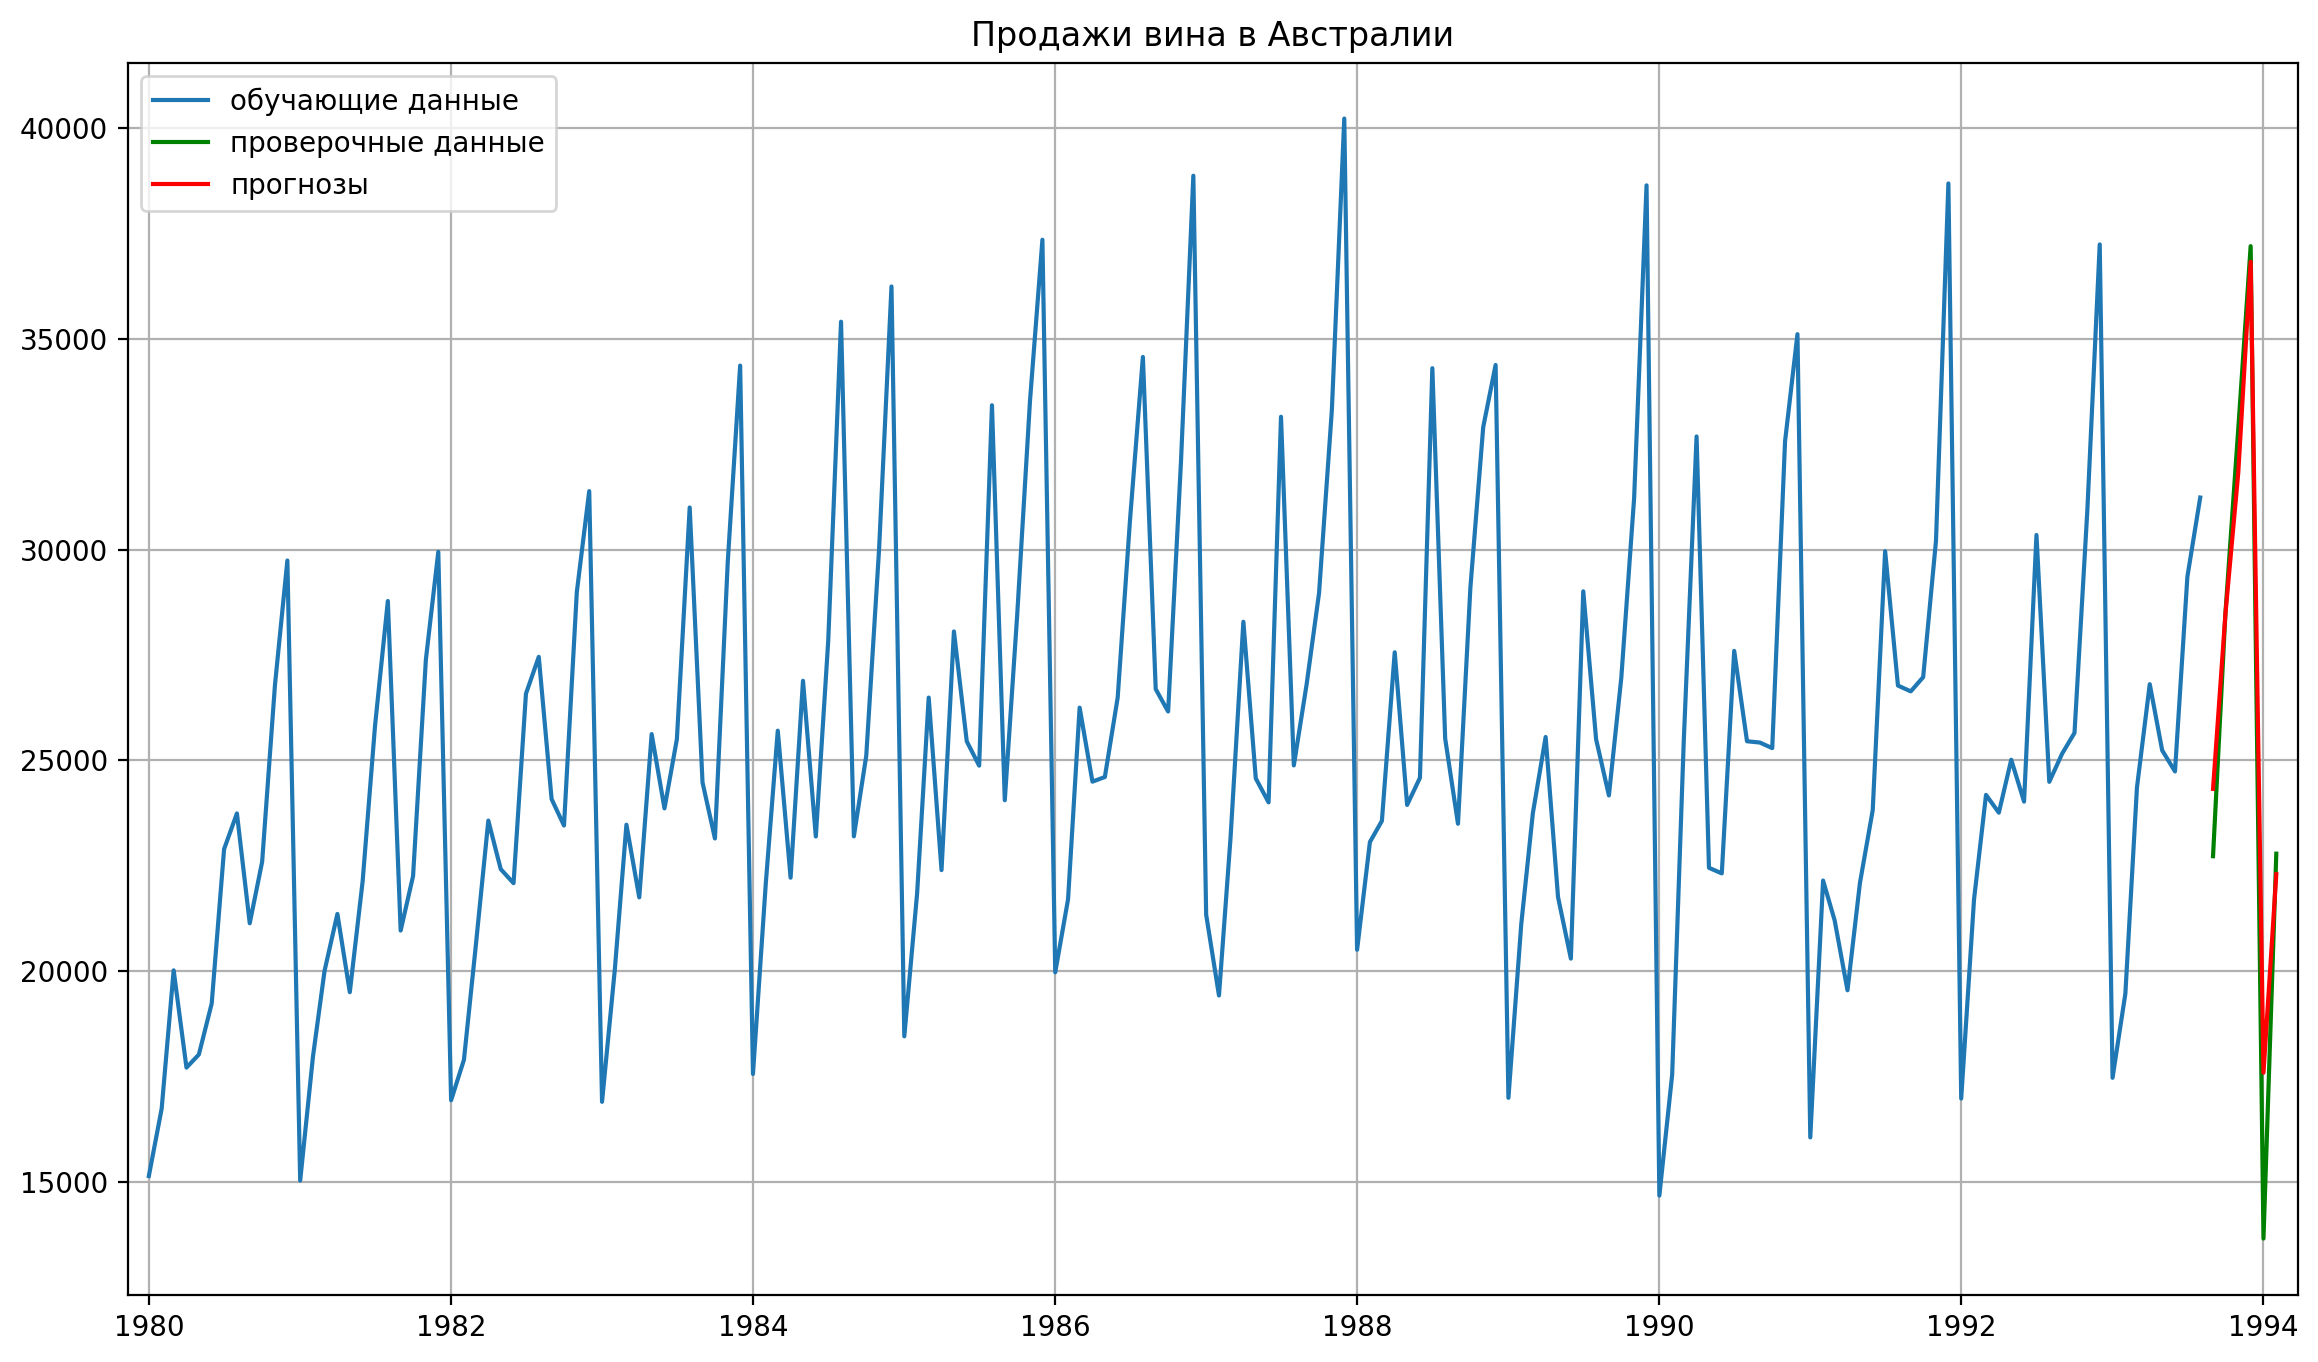

In [ ]:
# визуализируем временной ряд

# присваиваем прогнозам индексные метки
# проверочной выборки
ctbst_predictions = pd.Series(ctbst_predictions)
ctbst_predictions.index = valid.index

# задаем размер графика
fig, ax = plt.subplots(figsize=(14, 8))
# строим графики для обучающих данных,
# проверочных данных и прогнозов
ax.plot(y_train,
        label='обучающие данные')
ax.plot(y_valid,
        color='green',
        label='проверочные данные')
ax.plot(ctbst_predictions,
        color='red',
        label='прогнозы')
# задаем заголовок графика
ax.set_title("Продажи вина в Австралии")
# задаем начало оси x с отступом
ax.margins(x=0.01)
# задаем координатную сетку
ax.grid()
# задаем легенду
ax.legend();

In [ ]:
# создаем экземпляр класса StandardScaler
scaler = StandardScaler()

# создаем список признаков для стандартизации
num_cols = train.select_dtypes(
    exclude='object').columns.tolist()

# создадим копии обучающего и
# проверочного массивов признаков
tr = train.copy()
val = valid.copy()

# выполняем стандартизацию
scaler.fit(tr[num_cols])
tr[num_cols] = scaler.transform(tr[num_cols])
val[num_cols] = scaler.transform(val[num_cols])

# создаем модель гребневой регрессии
ridge_model = Ridge(alpha=0.01)
# обучаем модель гребневой регрессии
ridge_model.fit(tr, y_train)

# получаем прогнозы
ridge_predictions = ridge_model.predict(val)
# вычисляем RMSE на проверочной выборке
ridge_rmse = mean_squared_error(
    y_valid, ridge_predictions, squared=False)
ridge_rmse

2573.0766907797147

In [ ]:
# удаляем лаги и скользящие средние
# в обучающе-проверочном наборе
train_valid = train_valid[train_valid.columns.drop(
    list(train_valid.filter(regex='Lag_|Moving_mean_')))]

In [ ]:
# создаем обучающе-тестовый набор
train_test = pd.concat([train_valid, test], axis=0)
# создаем копию зависимой переменной и заменяем значения
# в наблюдениях, приходящихся на горизонт прогнозирования
# (тестовую часть), пропусками
y_train_test_with_nan = train_test['sales'].copy()
y_train_test_with_nan.iloc[-HORIZON:] = np.NaN
y_train_test_with_nan.tail(HORIZON + 2)

month
1994-01-01    13652.0
1994-02-01    22784.0
1994-03-01        NaN
1994-04-01        NaN
1994-05-01        NaN
1994-06-01        NaN
1994-07-01        NaN
1994-08-01        NaN
Name: sales, dtype: float64

In [ ]:
# создаем лаги и скользящие средние
train_test = calculate_lags_and_stats(
    train_test, y_train_test_with_nan,
    lags_range=list(range(6, 11, 2)),
    moving_stats_range=[6, 8],
    periods=1, min_periods=1,
    aggfunc='mean', seasonality=1)

In [ ]:
# выведем первые 5 наблюдений
train_test.head()

,sales,quarter,month,season,Lag_6,Lag_8,Lag_10,Moving_mean_6,Moving_mean_8
month,,,,,,,,,
1980-01-01,15136,1,1,0,NaN,NaN,NaN,NaN,NaN
1980-02-01,16733,1,2,0,NaN,NaN,NaN,15136.00,15136.00
1980-03-01,20016,1,3,1,NaN,NaN,NaN,15934.50,15934.50
1980-04-01,17708,2,4,1,NaN,NaN,NaN,17295.00,17295.00
1980-05-01,18019,2,5,1,NaN,NaN,NaN,17398.25,17398.25


In [ ]:
# создаем обучающий массив признаков,
# тестовый массив признаков, обучающий
# массив меток, тестовый массив меток
train, test, y_train, y_test = train_test_split(
    train_test.drop('sales', axis=1),
    train_test['sales'],
    test_size=HORIZON,
    shuffle=False)

In [ ]:
# временные рамки обучающей выборки
print('временные рамки обучающей выборки:',
      train.index[0].strftime('%Y-%m-%d'),
      train.index[-1].strftime('%Y-%m-%d'))
# смотрим первые 5 наблюдений обучающей выборки
train.head()

временные рамки обучающей выборки: 1980-01-01 1994-02-01


,quarter,month,season,Lag_6,Lag_8,Lag_10,Moving_mean_6,Moving_mean_8
month,,,,,,,,
1980-01-01,1,1,0,NaN,NaN,NaN,NaN,NaN
1980-02-01,1,2,0,NaN,NaN,NaN,15136.00,15136.00
1980-03-01,1,3,1,NaN,NaN,NaN,15934.50,15934.50
1980-04-01,2,4,1,NaN,NaN,NaN,17295.00,17295.00
1980-05-01,2,5,1,NaN,NaN,NaN,17398.25,17398.25


In [ ]:
# временные рамки тестовой выборки
print('временные рамки тестовой выборки:',
      test.index[0].strftime('%Y-%m-%d'),
      test.index[-1].strftime('%Y-%m-%d'))
# смотрим первые 5 наблюдений тестовой выборки
test.head()

временные рамки тестовой выборки: 1994-03-01 1994-08-01


,quarter,month,season,Lag_6,Lag_8,Lag_10,Moving_mean_6,Moving_mean_8
month,,,,,,,,
1994-03-01,1,3,1,22724.0,29356.0,25236.0,26285.166667,27287.625000
1994-04-01,2,4,1,28496.0,31234.0,24735.0,26997.400000,26992.142857
1994-05-01,2,5,1,32857.0,22724.0,29356.0,26622.750000,26285.166667
1994-06-01,2,6,2,37198.0,28496.0,31234.0,24544.666667,26997.400000
1994-07-01,3,7,2,13652.0,32857.0,22724.0,18218.000000,26622.750000


In [ ]:
# импутируем пропуски в лагах и скользящих средних
# средними значениями по первым n непропущенным
# наблюдениям, где n - порядок лага/ширина окна
pattern = train.columns.str.contains('Lag_|Moving_')
features = train.columns[pattern].tolist()
for i in features:
    train[i].fillna(
        train[i][train[i].notnull()].head(
            int(re.findall(r'\d+', i)[0])).mean(),
        axis=0, inplace=True)
train.head()

,quarter,month,season,Lag_6,Lag_8,Lag_10,Moving_mean_6,Moving_mean_8
month,,,,,,,,
1980-01-01,1,1,0,17806.5,19183.875,19719.5,16848.775,17351.208482
1980-02-01,1,2,0,17806.5,19183.875,19719.5,15136.000,15136.000000
1980-03-01,1,3,1,17806.5,19183.875,19719.5,15934.500,15934.500000
1980-04-01,2,4,1,17806.5,19183.875,19719.5,17295.000,17295.000000
1980-05-01,2,5,1,17806.5,19183.875,19719.5,17398.250,17398.250000


In [ ]:
# обучаем модель CatBoost
ctbst_model.fit(
    train, y_train,
    eval_set=(test, y_test),
    plot=True);

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [ ]:
# получаем прогнозы
ctbst_predictions = ctbst_model.predict(test)
# вычисляем RMSE на тестовой выборке
ctbst_rmse = mean_squared_error(
    y_test, ctbst_predictions, squared=False)
ctbst_rmse

2007.9969479625

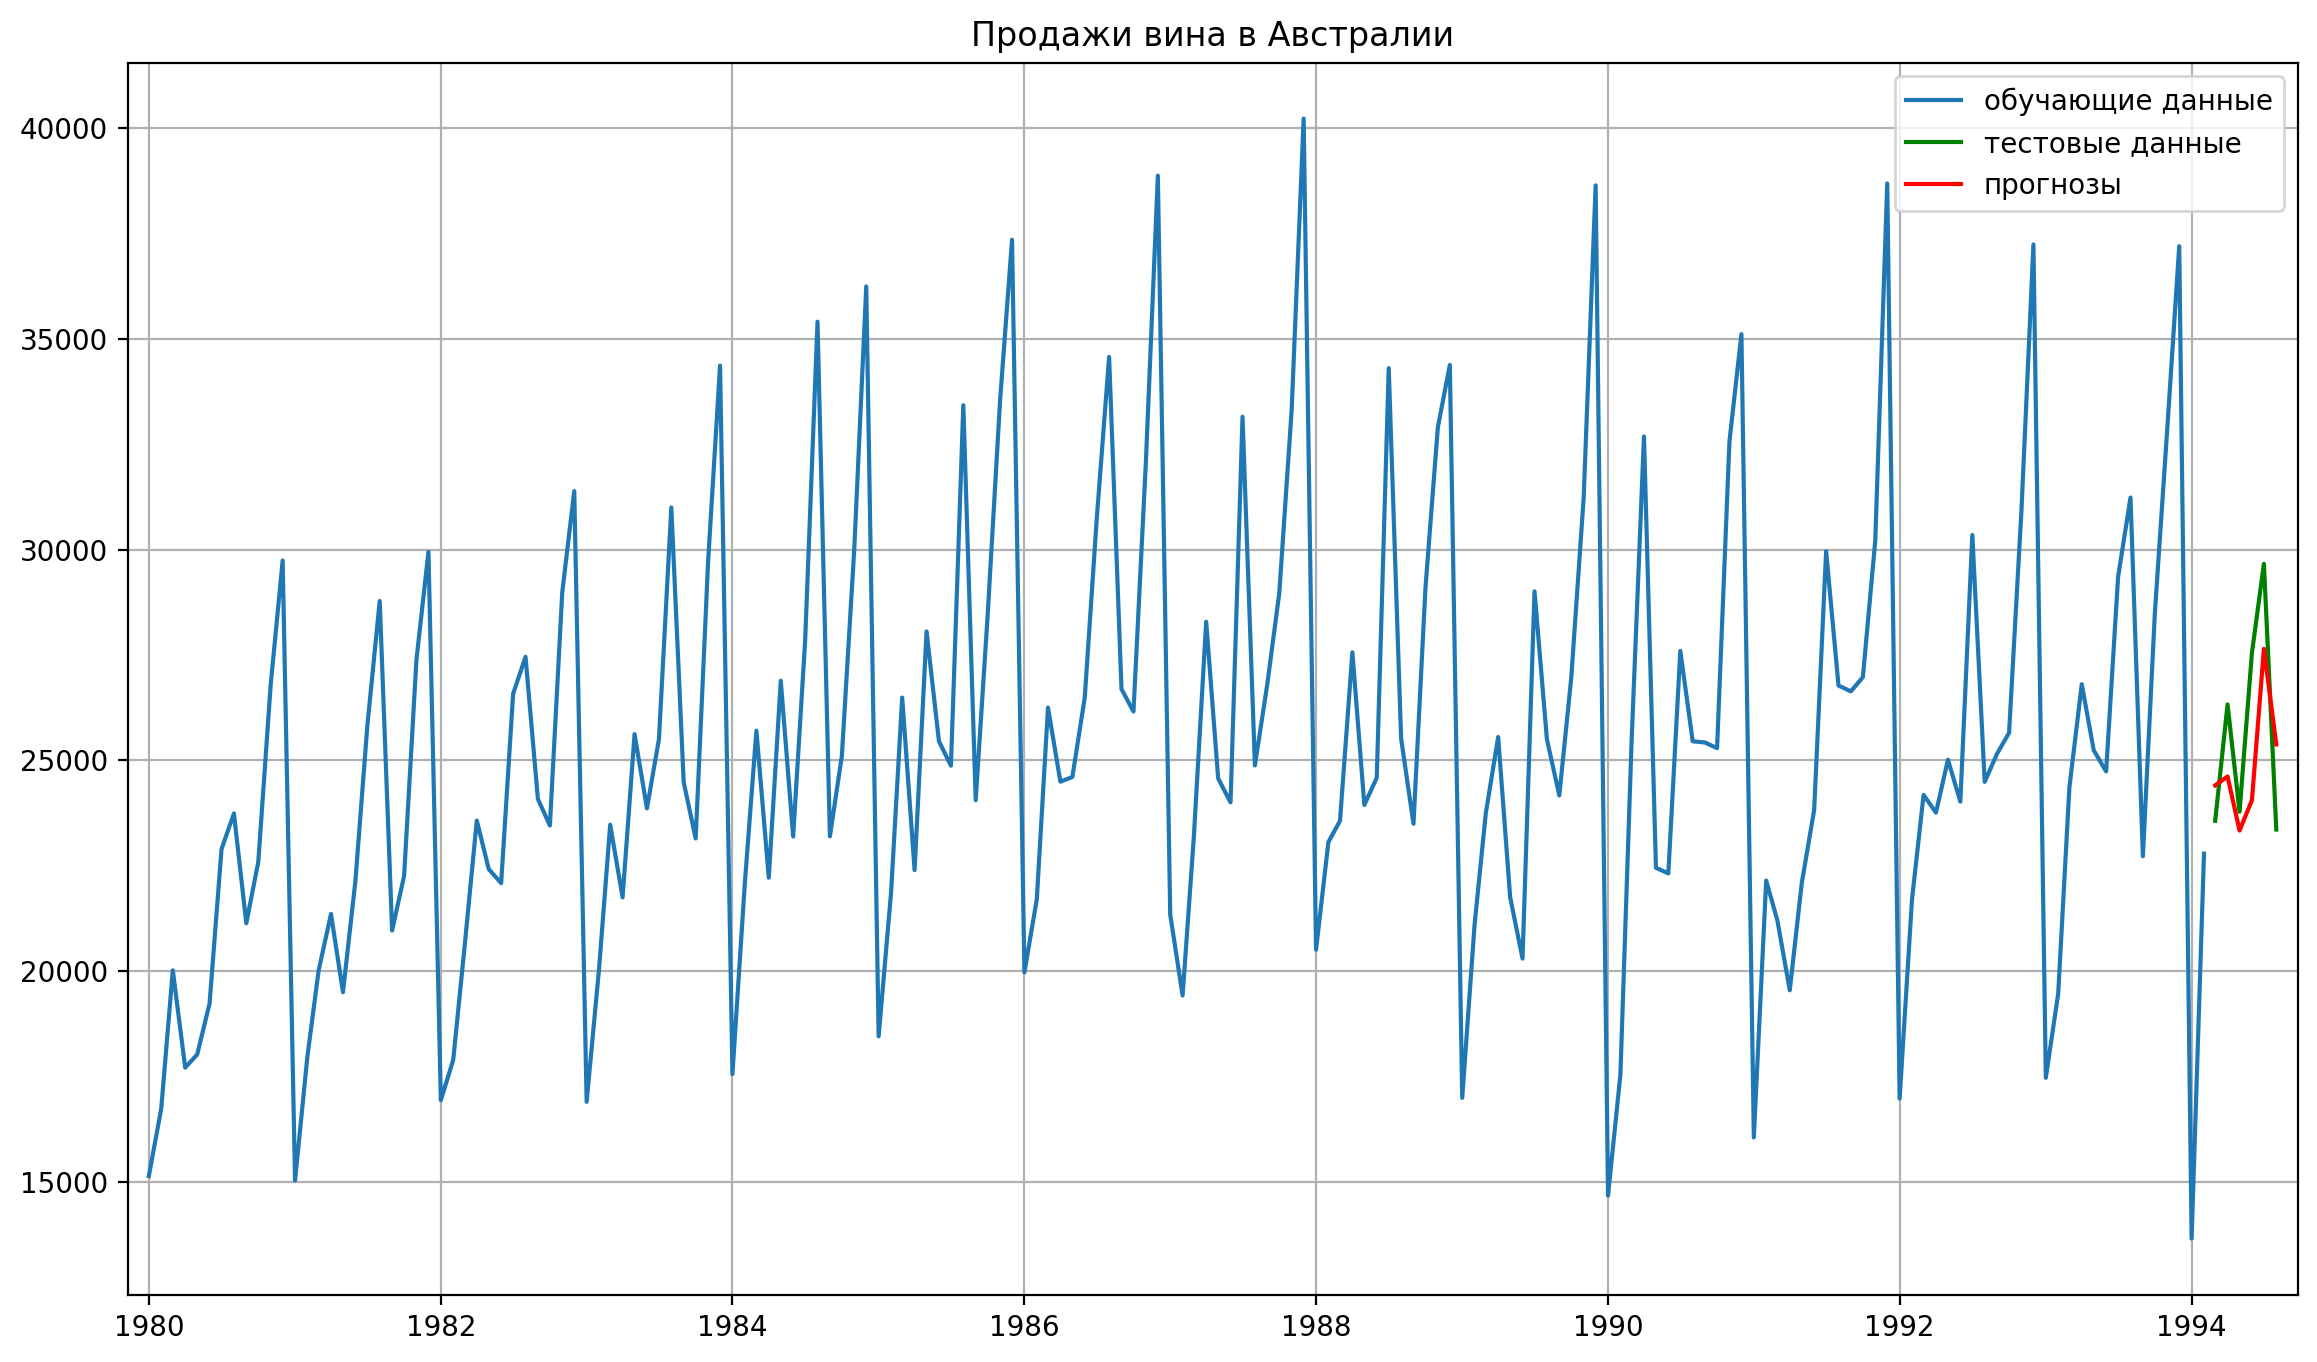

In [ ]:
# визуализируем временной ряд

# присваиваем прогнозам индексные метки
# тестовой выборки
ctbst_predictions = pd.Series(ctbst_predictions)
ctbst_predictions.index = test.index

# задаем размер графика
fig, ax = plt.subplots(figsize=(14, 8))
# строим графики для обучающих данных,
# тестовых данных и прогнозов
ax.plot(y_train,
        label='обучающие данные')
ax.plot(y_test,
        color='green',
        label='тестовые данные')
ax.plot(ctbst_predictions,
        color='red',
        label='прогнозы')
# задаем заголовок графика
ax.set_title("Продажи вина в Австралии")
# задаем начало оси x с отступом
ax.margins(x=0.01)
# задаем координатную сетку
ax.grid()
# задаем легенду
ax.legend();

In [ ]:
# удаляем лаги и скользящие средние в
# обучающе-тестовом наборе и присваиваем
# ему более нативное имя
hist_data = train_test[train_test.columns.drop(
    list(train_test.filter(regex='Lag_|Moving_mean_')))].copy()

In [ ]:
# формируем исторический массив меток
# и исторический массив признаков
y_hist_data = hist_data.pop('sales')

In [ ]:
# создаем лаги и скользящие средние
hist_data = calculate_lags_and_stats(
    hist_data, y_hist_data,
    lags_range=list(range(6, 11, 2)),
    moving_stats_range=[6, 8],
    periods=1, min_periods=1,
    aggfunc='mean', seasonality=1)

In [ ]:
# выведем первые 5 наблюдений
hist_data.head()

,quarter,month,season,Lag_6,Lag_8,Lag_10,Moving_mean_6,Moving_mean_8
month,,,,,,,,
1980-01-01,1,1,0,NaN,NaN,NaN,NaN,NaN
1980-02-01,1,2,0,NaN,NaN,NaN,15136.00,15136.00
1980-03-01,1,3,1,NaN,NaN,NaN,15934.50,15934.50
1980-04-01,2,4,1,NaN,NaN,NaN,17295.00,17295.00
1980-05-01,2,5,1,NaN,NaN,NaN,17398.25,17398.25


In [ ]:
# импутируем пропуски в лагах и скользящих средних
# средними значениями по первым n непропущенным
# наблюдениям, где n - ширина окна
pattern = hist_data.columns.str.contains('Lag_|Moving_')
features = hist_data.columns[pattern].tolist()
for i in features:
    hist_data[i].fillna(
        hist_data[i][hist_data[i].notnull()].head(
            int(re.findall(r'\d+', i)[0])).mean(),
        axis=0, inplace=True)
hist_data.head()

,quarter,month,season,Lag_6,Lag_8,Lag_10,Moving_mean_6,Moving_mean_8
month,,,,,,,,
1980-01-01,1,1,0,17806.5,19183.875,19719.5,16848.775,17351.208482
1980-02-01,1,2,0,17806.5,19183.875,19719.5,15136.000,15136.000000
1980-03-01,1,3,1,17806.5,19183.875,19719.5,15934.500,15934.500000
1980-04-01,2,4,1,17806.5,19183.875,19719.5,17295.000,17295.000000
1980-05-01,2,5,1,17806.5,19183.875,19719.5,17398.250,17398.250000


In [ ]:
# создаем модель CatBoost для обучения
# на всей исторической выборке
hist_ctbst_model = CatBoostRegressor(
    random_seed=42,
    n_estimators=600,
    learning_rate=0.05,
    loss_function='MAE',
    depth=9,
    logging_level='Silent')

# обучаем модель CatBoost на
# всей исторической выборке
hist_ctbst_model.fit(
    hist_data, y_hist_data);

In [ ]:
# создаем датафрейм новых данных, длина которого равна
# горизонту прогнозирования, т.е. составляет 6 месяцев
new_data = pd.DataFrame(index=pd.date_range(
    start='1994-09-01', periods=HORIZON, freq='MS'))
new_data

""
1994-09-01
1994-10-01
1994-11-01
1994-12-01
1995-01-01
1995-02-01


In [ ]:
# создаем календарные признаки
new_data = create_calendar_vars(new_data)
new_data

,quarter,month,season
1994-09-01,3,9,3
1994-10-01,4,10,3
1994-11-01,4,11,3
1994-12-01,4,12,0
1995-01-01,1,1,0
1995-02-01,1,2,0


In [ ]:
# формируем массив меток для новых данных,
# состоящих из значений NaN, по длине
# равный горизонту прогнозирования
dates = pd.date_range(start='1994-09-01',
                      periods=HORIZON,
                      freq='MS')
y_new_data = pd.Series(np.NaN, index=dates)
y_new_data

1994-09-01   NaN
1994-10-01   NaN
1994-11-01   NaN
1994-12-01   NaN
1995-01-01   NaN
1995-02-01   NaN
Freq: MS, dtype: float64

In [ ]:
# формируем объединенный массив меток из исторического
# массива меток и массива меток для новых данных
y_hist_data_new_data_with_nan = pd.concat(
    [y_hist_data, y_new_data], axis=0)
y_hist_data_new_data_with_nan.tail(HORIZON + 2)

1994-07-01    29660.0
1994-08-01    23356.0
1994-09-01        NaN
1994-10-01        NaN
1994-11-01        NaN
1994-12-01        NaN
1995-01-01        NaN
1995-02-01        NaN
dtype: float64

In [ ]:
# создаем лаги и скользящие средние
new_data = calculate_lags_and_stats(
    new_data, y_hist_data_new_data_with_nan,
    lags_range=list(range(6, 11, 2)),
    moving_stats_range=[6, 8],
    periods=1, min_periods=1,
    aggfunc='mean', seasonality=1)

In [ ]:
# выведем первые 5 наблюдений
new_data.head()

,quarter,month,season,Lag_6,Lag_8,Lag_10,Moving_mean_6,Moving_mean_8
1994-09-01,3,9,3,23565.0,13652.0,32857.0,25705.333333,23833.500000
1994-10-01,4,10,3,26323.0,22784.0,37198.0,26133.400000,25288.000000
1994-11-01,4,11,3,23779.0,23565.0,13652.0,26086.000000,25705.333333
1994-12-01,4,12,0,27549.0,26323.0,22784.0,26855.000000,26133.400000
1995-01-01,1,1,0,29660.0,23779.0,23565.0,26508.000000,26086.000000


In [ ]:
# получаем прогнозы для новых данных
new_data_predictions = hist_ctbst_model.predict(new_data)
new_data_pred = pd.Series(new_data_predictions)
new_data_pred.index = new_data.index
new_data_pred

1994-09-01    24879.071417
1994-10-01    27742.364082
1994-11-01    31794.016839
1994-12-01    34552.389683
1995-01-01    18096.807786
1995-02-01    23084.023440
Freq: MS, dtype: float64

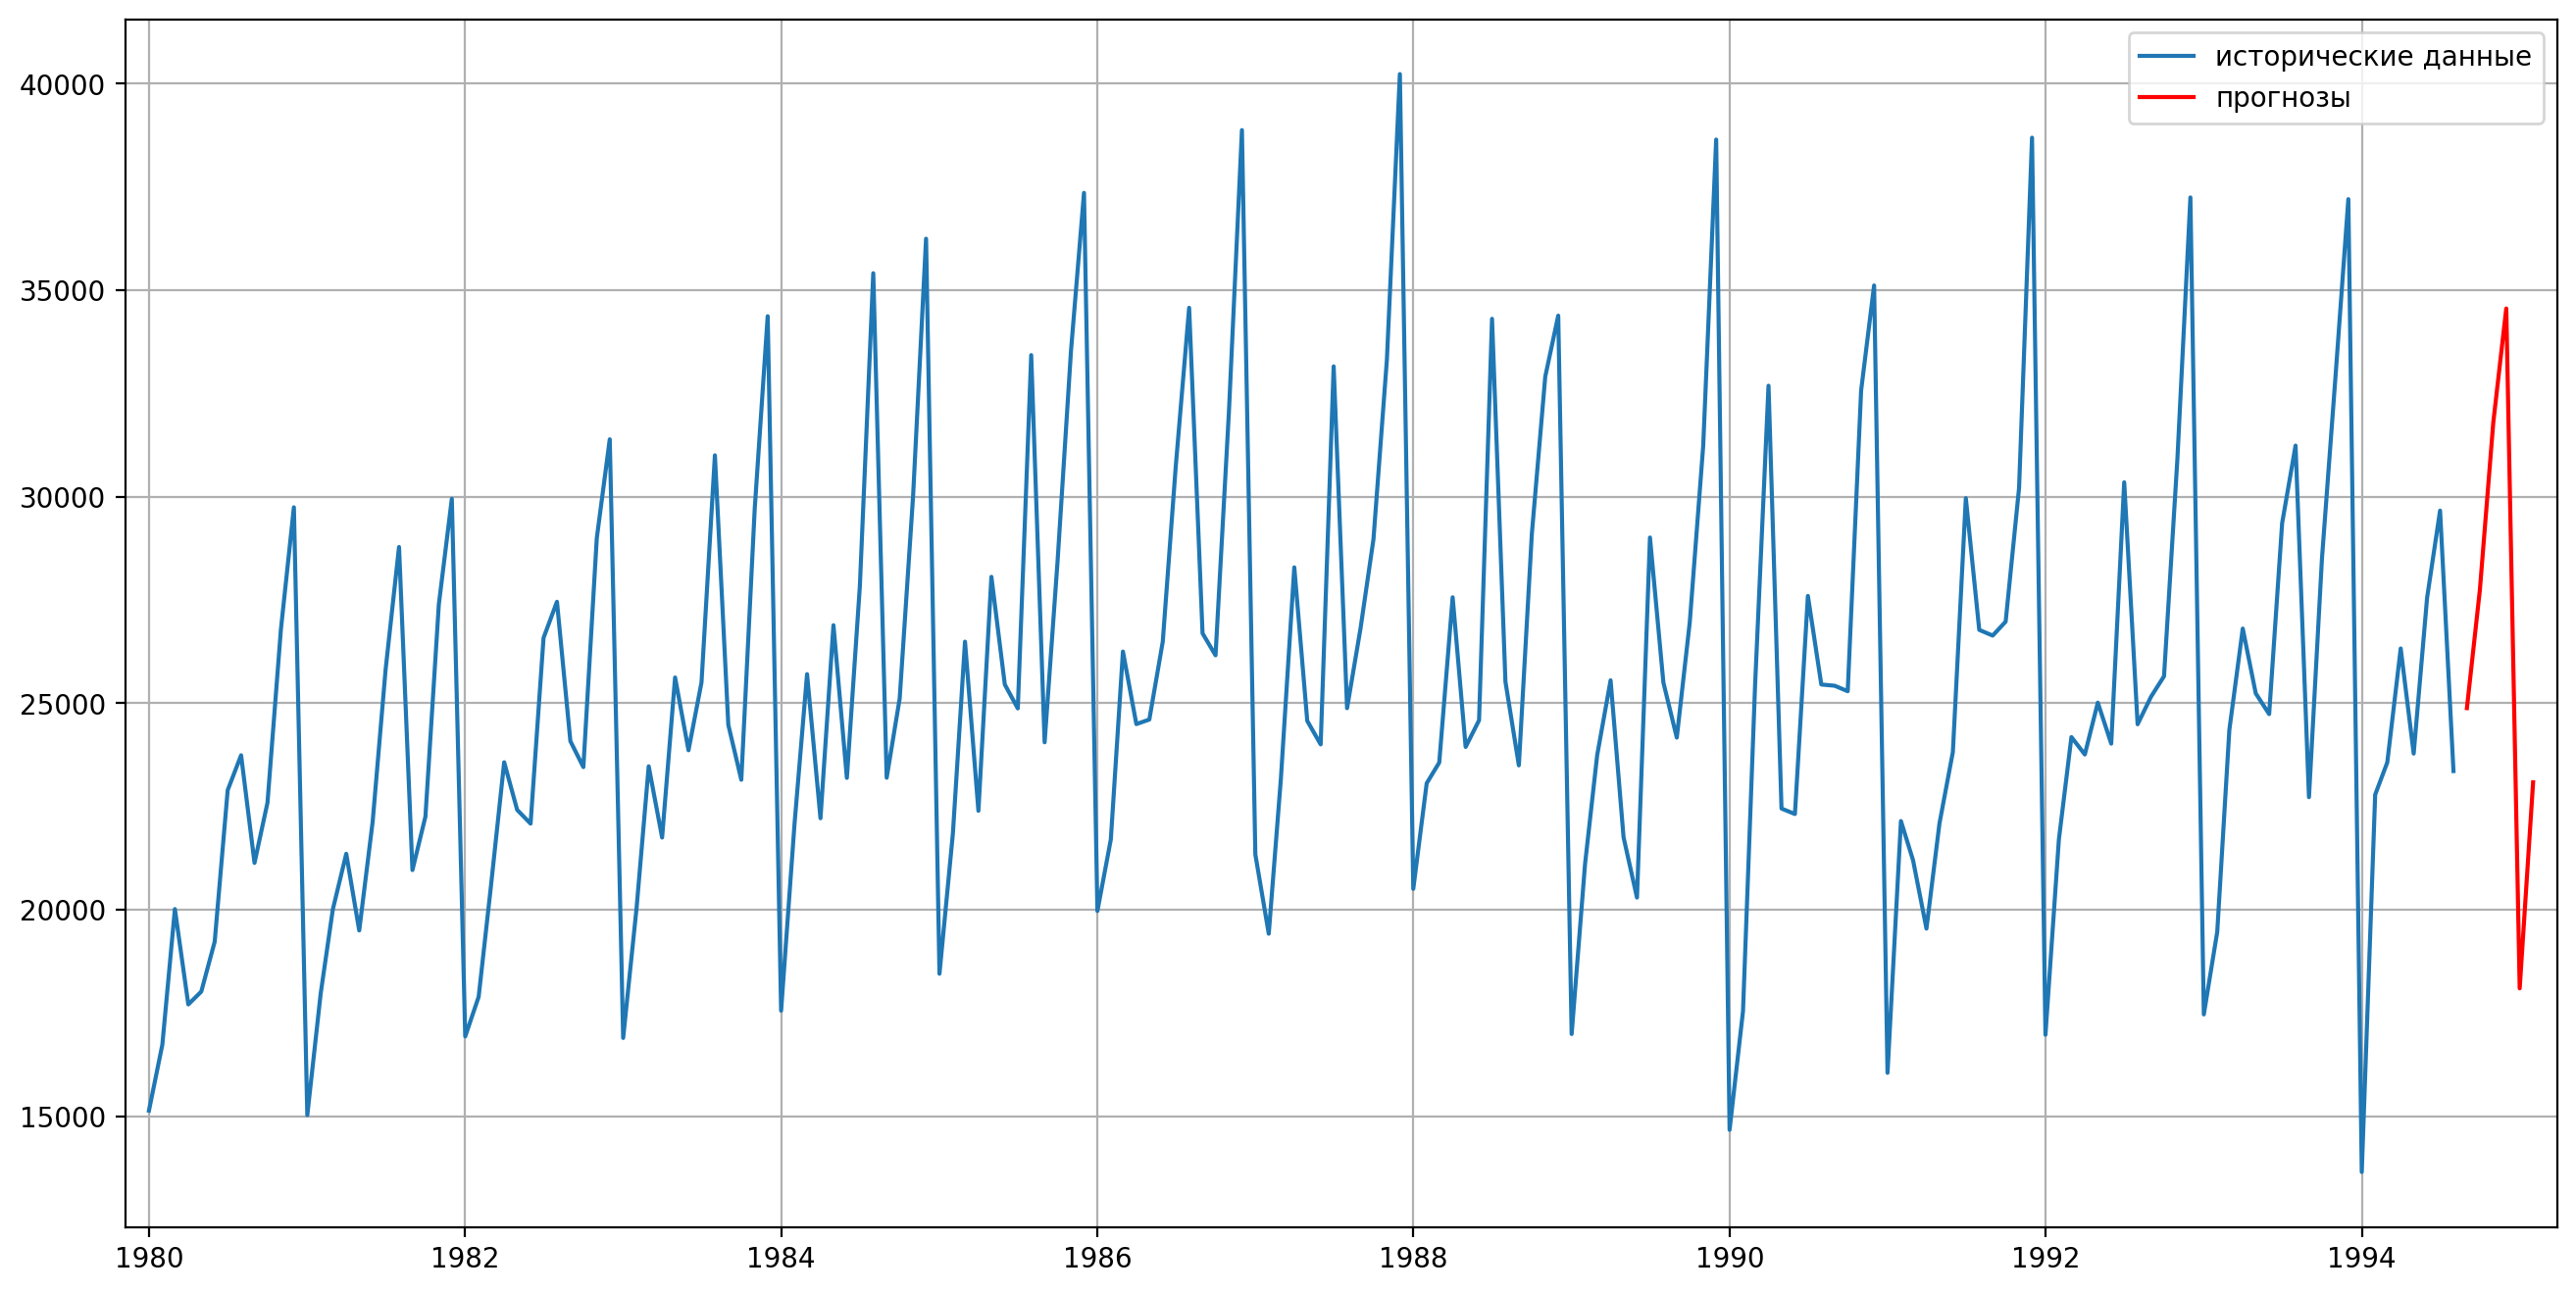

In [ ]:
# задаем размер графика
fig, ax = plt.subplots(figsize=(16, 8))
# строим графики для исторических данных,
# новых данных, трендов и прогнозов
ax.plot(y_hist_data, label='исторические данные')
ax.plot(new_data_pred, color='red', label='прогнозы')
# задаем начало оси x с отступом
ax.margins(x=0.01)
# задаем координатную сетку
ax.grid()
# задаем легенду
ax.legend();

# Больше материалов в рамках подписки вы найдете по адресу https://boosty.to/gewissta